In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from random import randint
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import cross_val_score, KFold
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_predict
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from datetime import timedelta
from math import sqrt
from scipy.stats import boxcox
from scipy.special import inv_boxcox
from sklearn.preprocessing import MinMaxScaler

In [ ]:
df = pd.read_csv('datapoints.csv')

In [ ]:
print("Stations in the DataFrame:", df['Station'].unique())
print("Models in the DataFrame:", df['Model'].unique())

Stations in the DataFrame: [ 1  2  3  4  5  6  7  8  9 10]
Models in the DataFrame: ['LSTM' 'BiLSTM' 'Feedback' 'BiFeedback']


In [ ]:
print(df)

    Station       Model       MSE       MAE      RMSE      MAPE
0         1        LSTM  0.062913  0.222441  0.250825  0.606432
1         1      BiLSTM  0.057317  0.204665  0.239409  0.571725
2         1    Feedback  0.039935  0.144539  0.199837  0.306241
3         1  BiFeedback  0.038275  0.144004  0.195640  0.300817
4         2        LSTM  0.027423  0.149868  0.165598  0.501657
5         2      BiLSTM  0.016400  0.081600  0.128063  0.191809
6         2    Feedback  0.018001  0.109814  0.134166  0.365493
7         2  BiFeedback  0.015512  0.084478  0.124548  0.253399
8         3        LSTM  0.020469  0.111214  0.143069  0.343565
9         3      BiLSTM  0.010370  0.071174  0.101834  0.217217
10        3    Feedback  0.029125  0.127953  0.170660  0.390439
11        3  BiFeedback  0.007959  0.054458  0.089216  0.162159
12        4        LSTM  0.051348  0.190536  0.226602  0.376073
13        4      BiLSTM  0.065530  0.224473  0.255988  0.462867
14        4    Feedback  0.011004  0.085

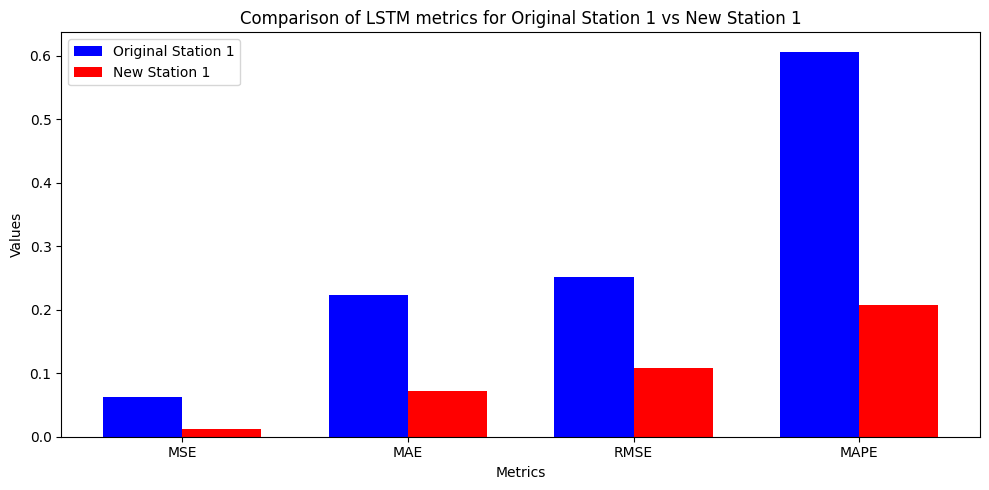

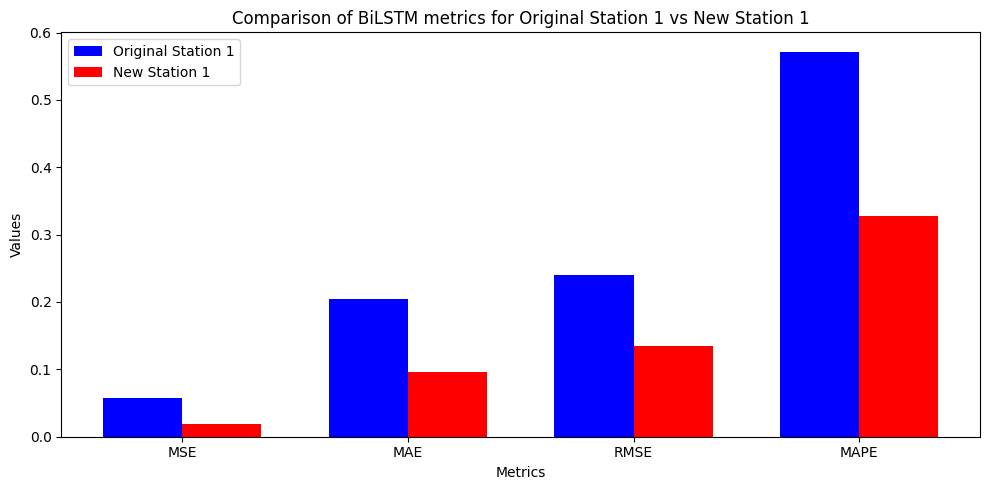

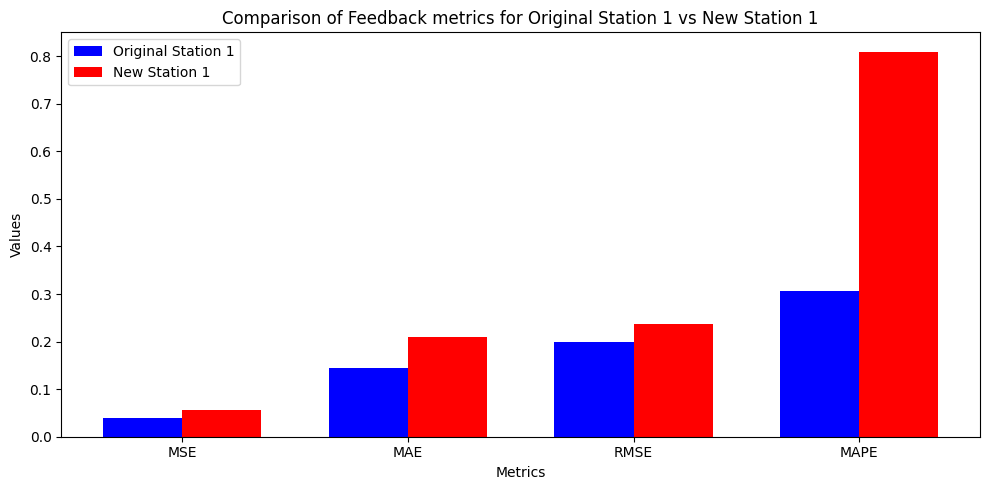

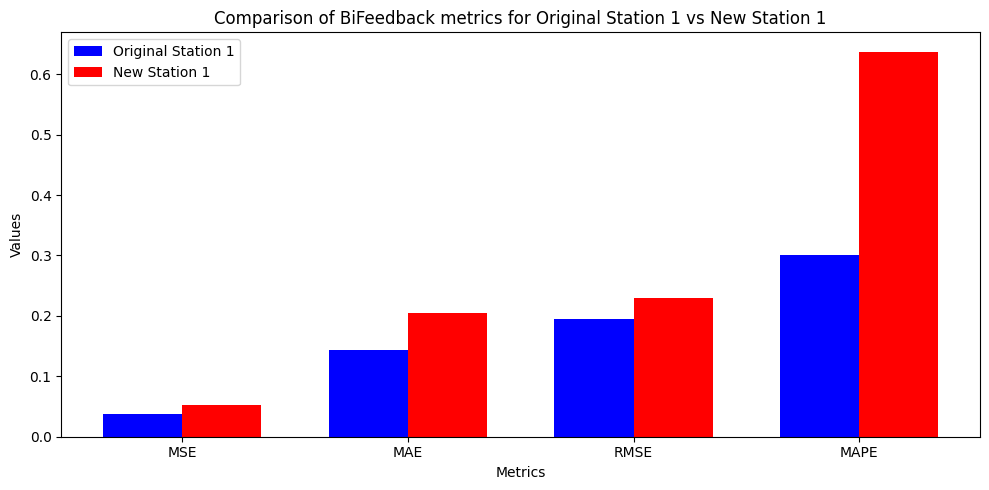

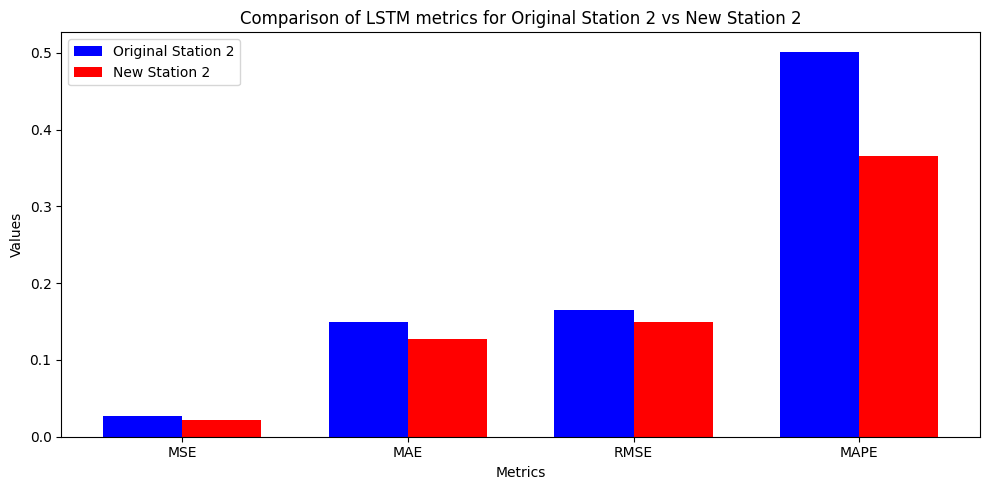

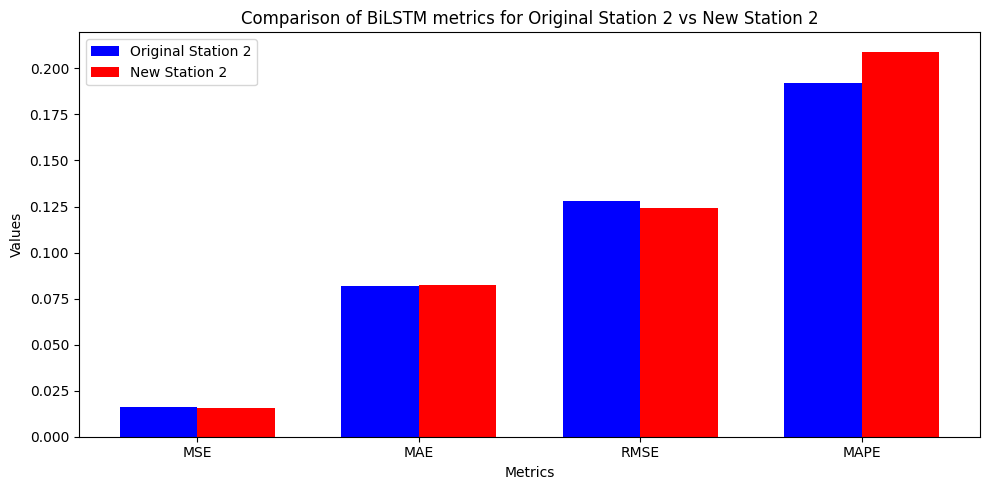

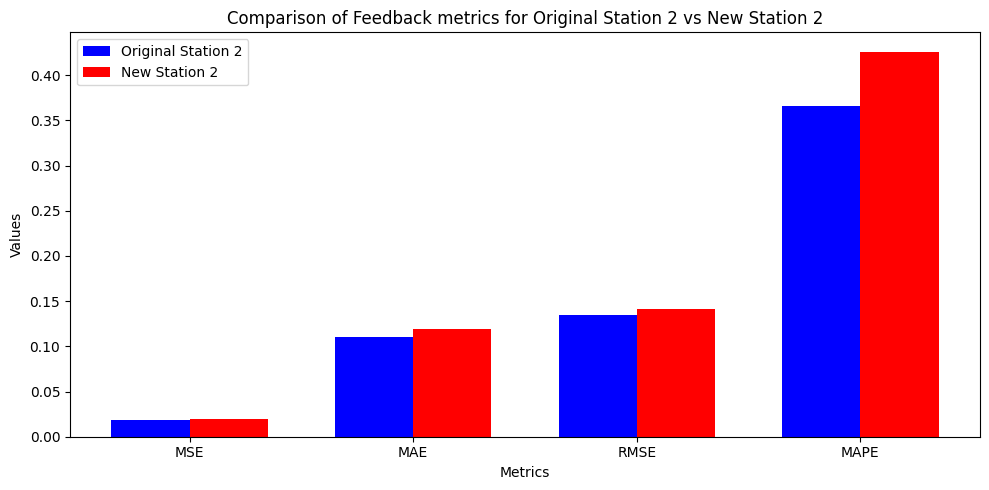

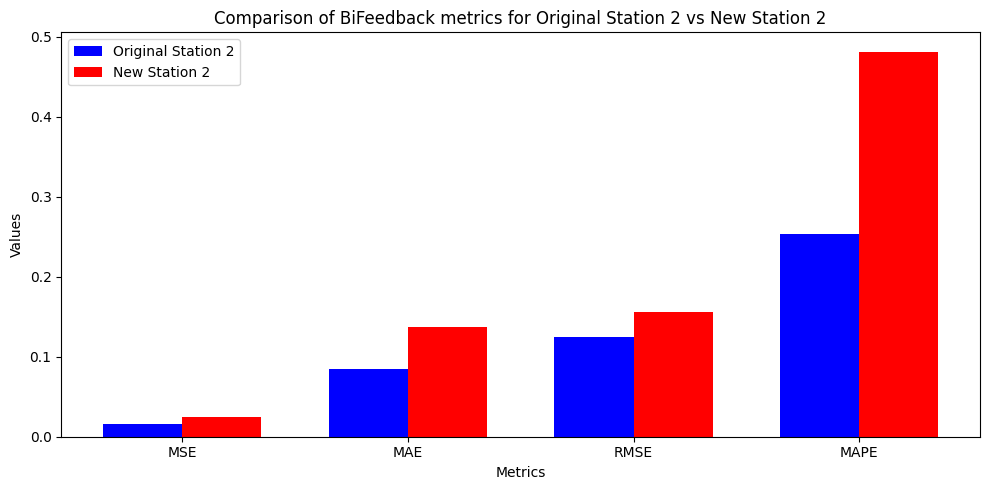

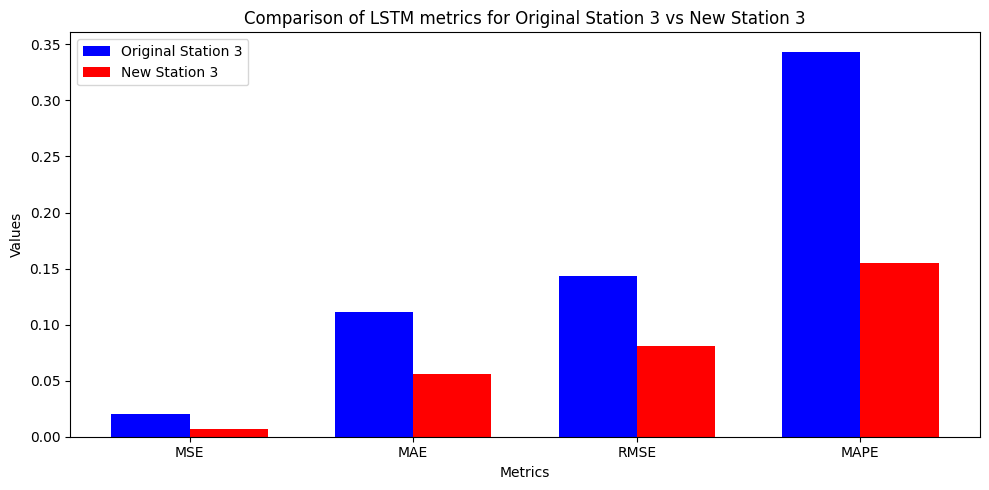

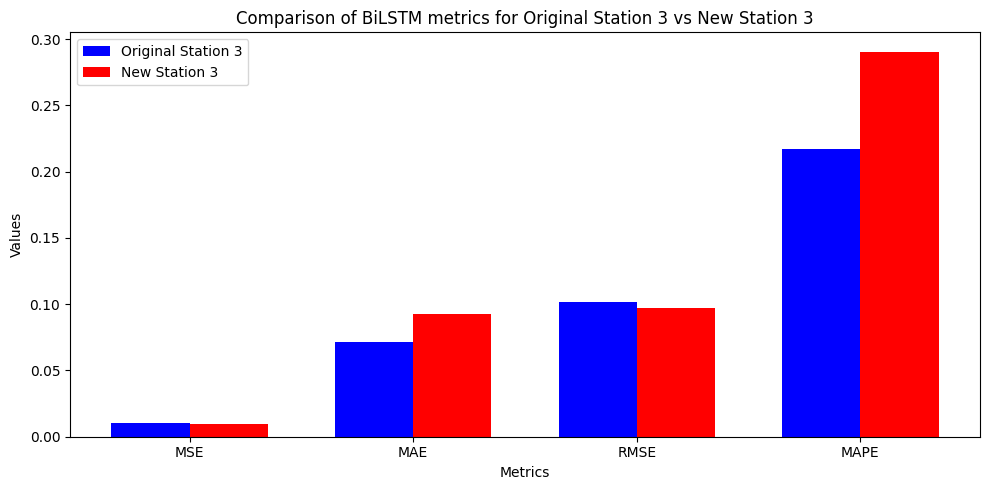

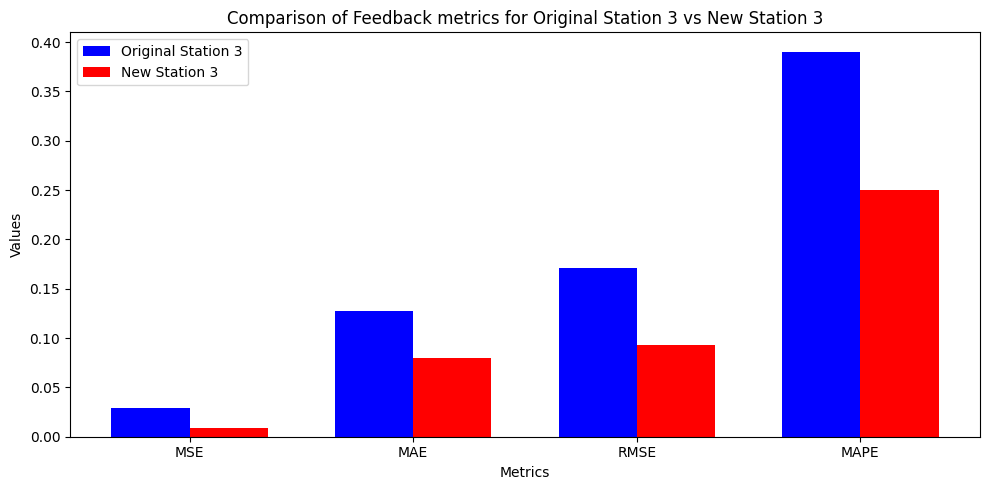

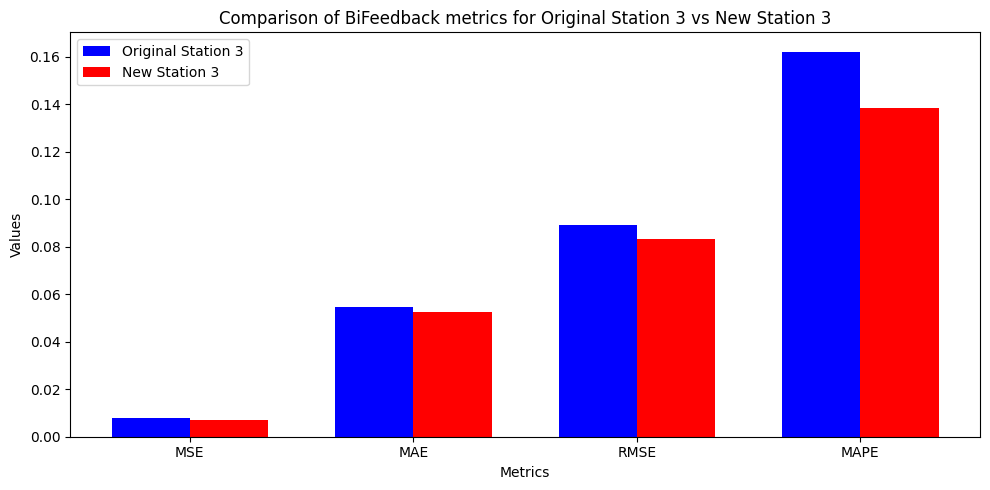

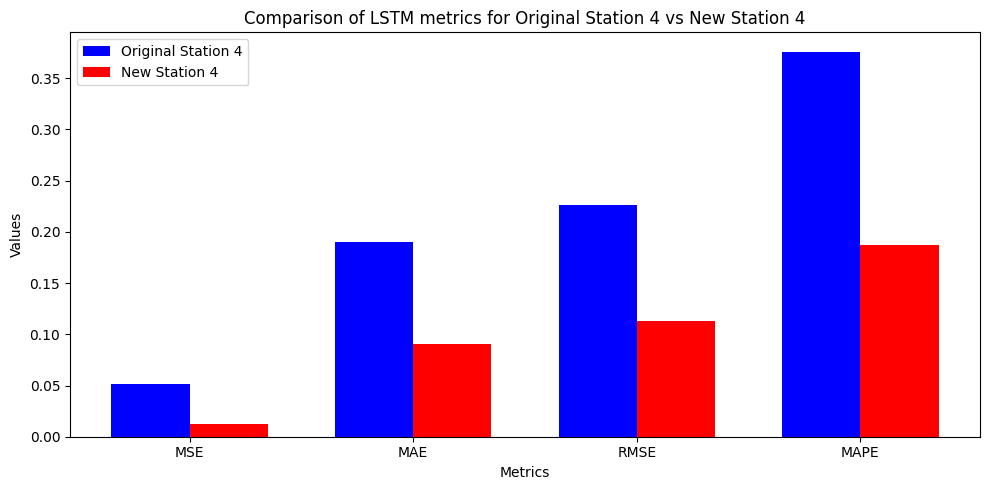

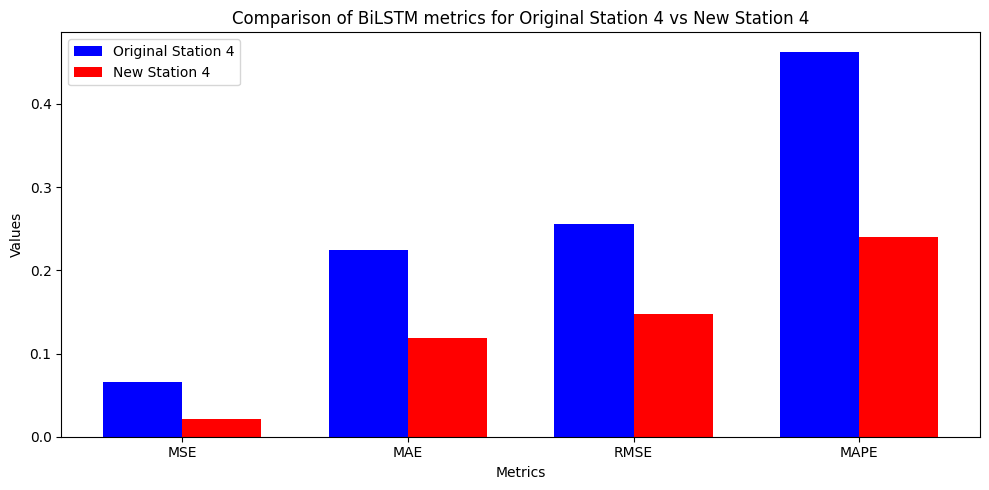

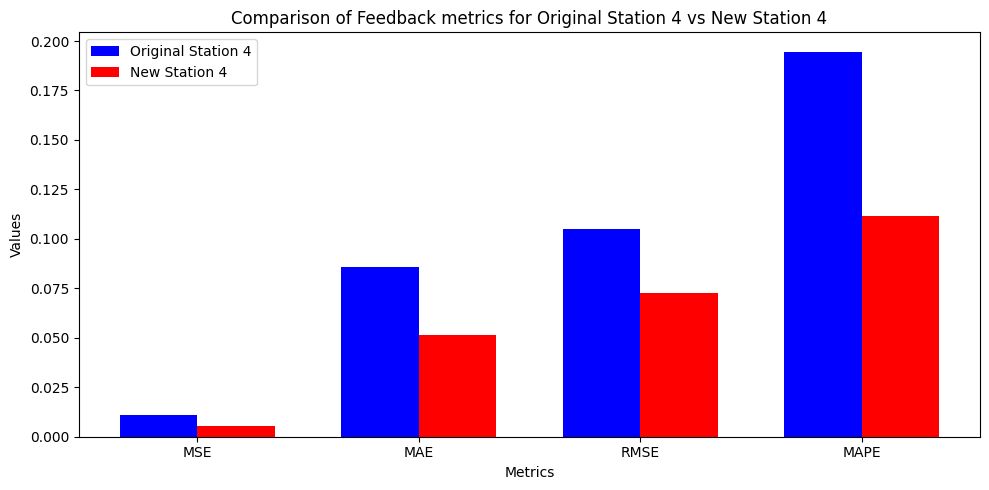

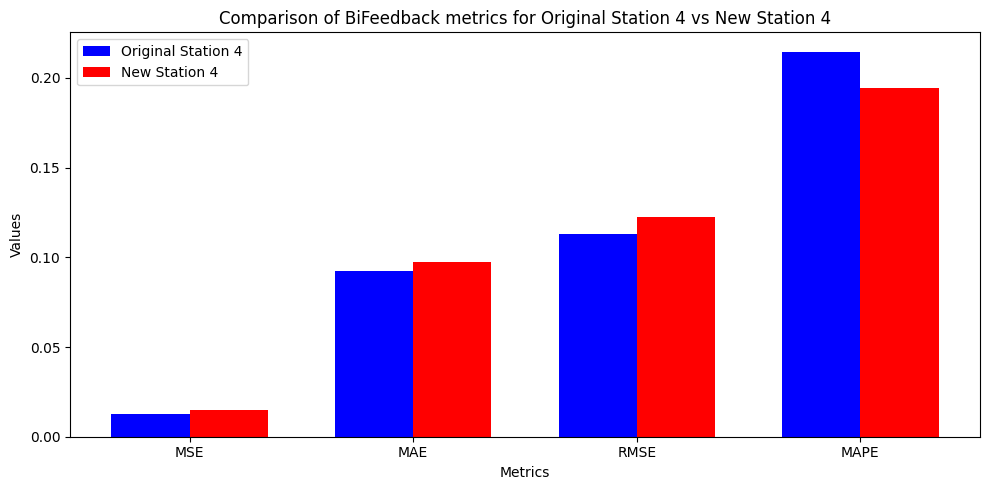

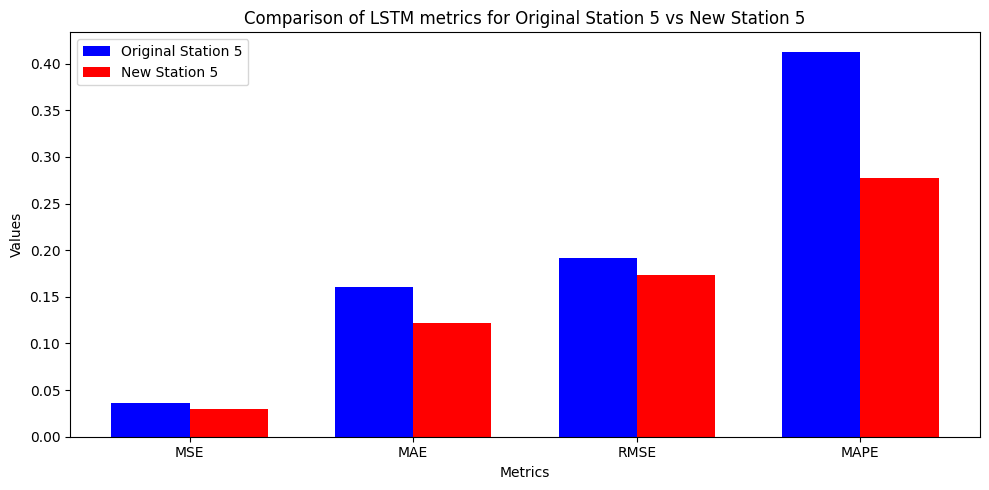

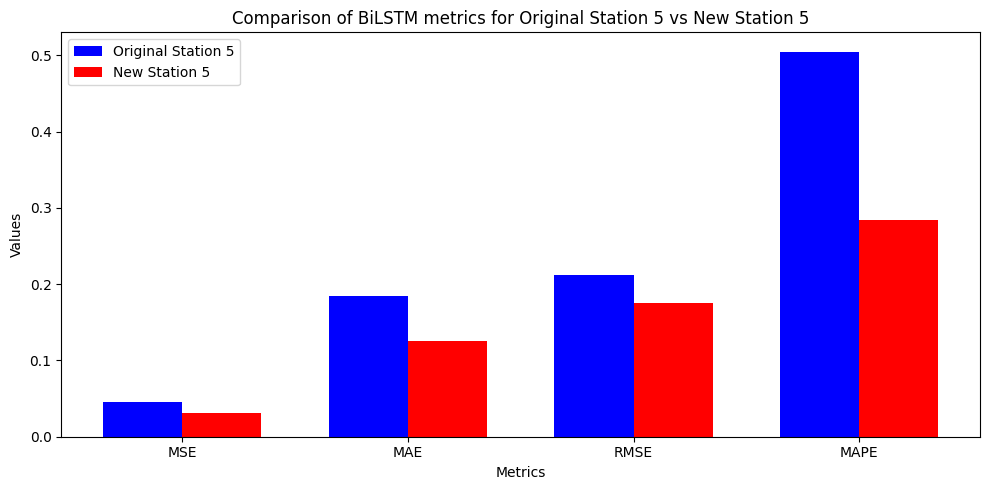

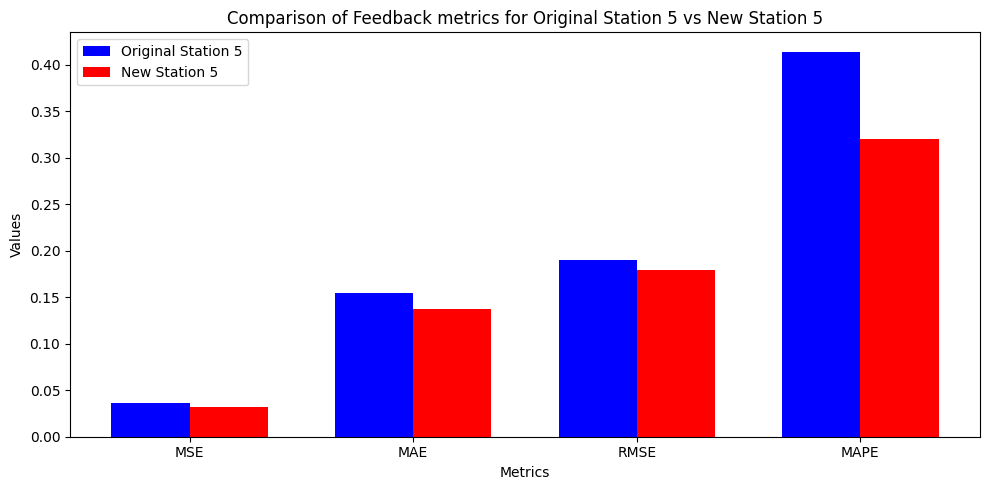

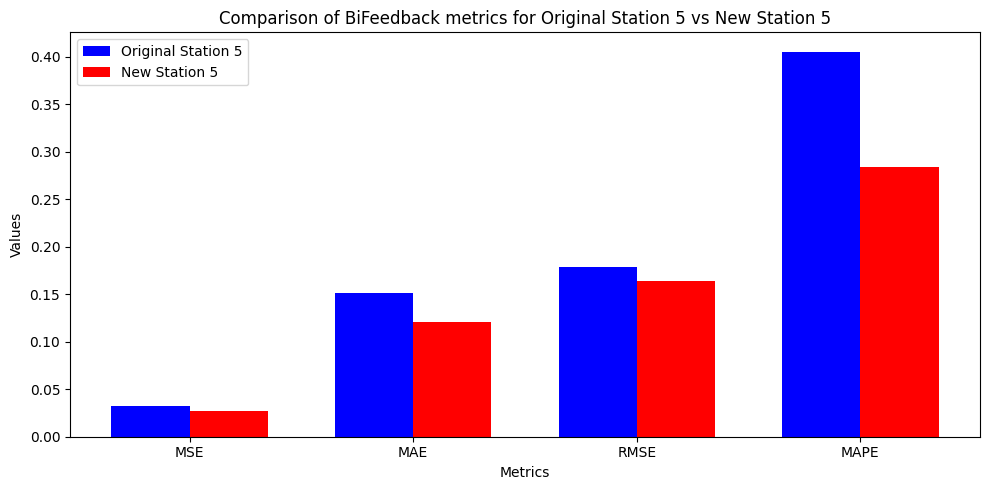

In [ ]:



def plot_comparisons(stations_pair, model):
    station1, station6 = stations_pair
    data1 = df[(df['Station'] == station1) & (df['Model'] == model)]
    data6 = df[(df['Station'] == station6) & (df['Model'] == model)]

    metrics = ['MSE', 'MAE', 'RMSE', 'MAPE']
    bar_width = 0.35
    index = np.arange(len(metrics))

    fig, ax = plt.subplots(figsize=(10, 5))
    bar1 = ax.bar(index, data1[metrics].values[0], bar_width, label=f'Original Station {station1}', color='blue')
    bar2 = ax.bar(index + bar_width, data6[metrics].values[0], bar_width, label=f'New Station {station1}', color='red')

    ax.set_xlabel('Metrics')
    ax.set_ylabel('Values')
    ax.set_title(f'Comparison of {model} metrics for Original Station {station1} vs New Station {station1}')
    ax.set_xticks(index + bar_width / 2)
    ax.set_xticklabels(metrics)
    ax.legend()

    plt.tight_layout()
    plt.show()

# Loop through the station pairs and models to create the plots
station_pairs = [(1, 6), (2, 7), (3, 8), (4, 9), (5, 10)]
models = ['LSTM', 'BiLSTM', 'Feedback', 'BiFeedback']

for stations_pair in station_pairs:
    for model in models:
        plot_comparisons(stations_pair, model)


In [ ]:
def plot_comparisons(stations_pair, models, df, filename):
    station1, station6 = stations_pair
    metrics = ['MSE', 'MAE', 'RMSE', 'MAPE']
    bar_width = 0.35
    index = np.arange(len(metrics))

    fig, axs = plt.subplots(2, 2, figsize=(20, 10))  # Create a 2x2 grid of subplots
    axs = axs.flatten()  # Flatten the 2x2 grid to easily iterate over it

    for idx, model in enumerate(models):
        data1 = df[(df['Station'] == station1) & (df['Model'] == model)]
        data6 = df[(df['Station'] == station6) & (df['Model'] == model)]

        ax = axs[idx]
        bar1 = ax.bar(index, data1[metrics].values[0], bar_width, label=f'Original Model', color='dodgerblue')
        bar2 = ax.bar(index + bar_width, data6[metrics].values[0], bar_width, label=f'Multivariate Model', color='crimson')

        ax.set_xlabel('Metrics')
        ax.set_ylabel('Values')
        ax.set_title(f'{model} metrics for Original Station {station1} vs Modified Station {station1}')
        ax.set_xticks(index + bar_width / 2)
        ax.set_xticklabels(metrics)
        ax.legend()

    plt.tight_layout()
    plt.savefig(f"{filename}.pdf", format='pdf')  # Save the figure to a PDF
    plt.show()

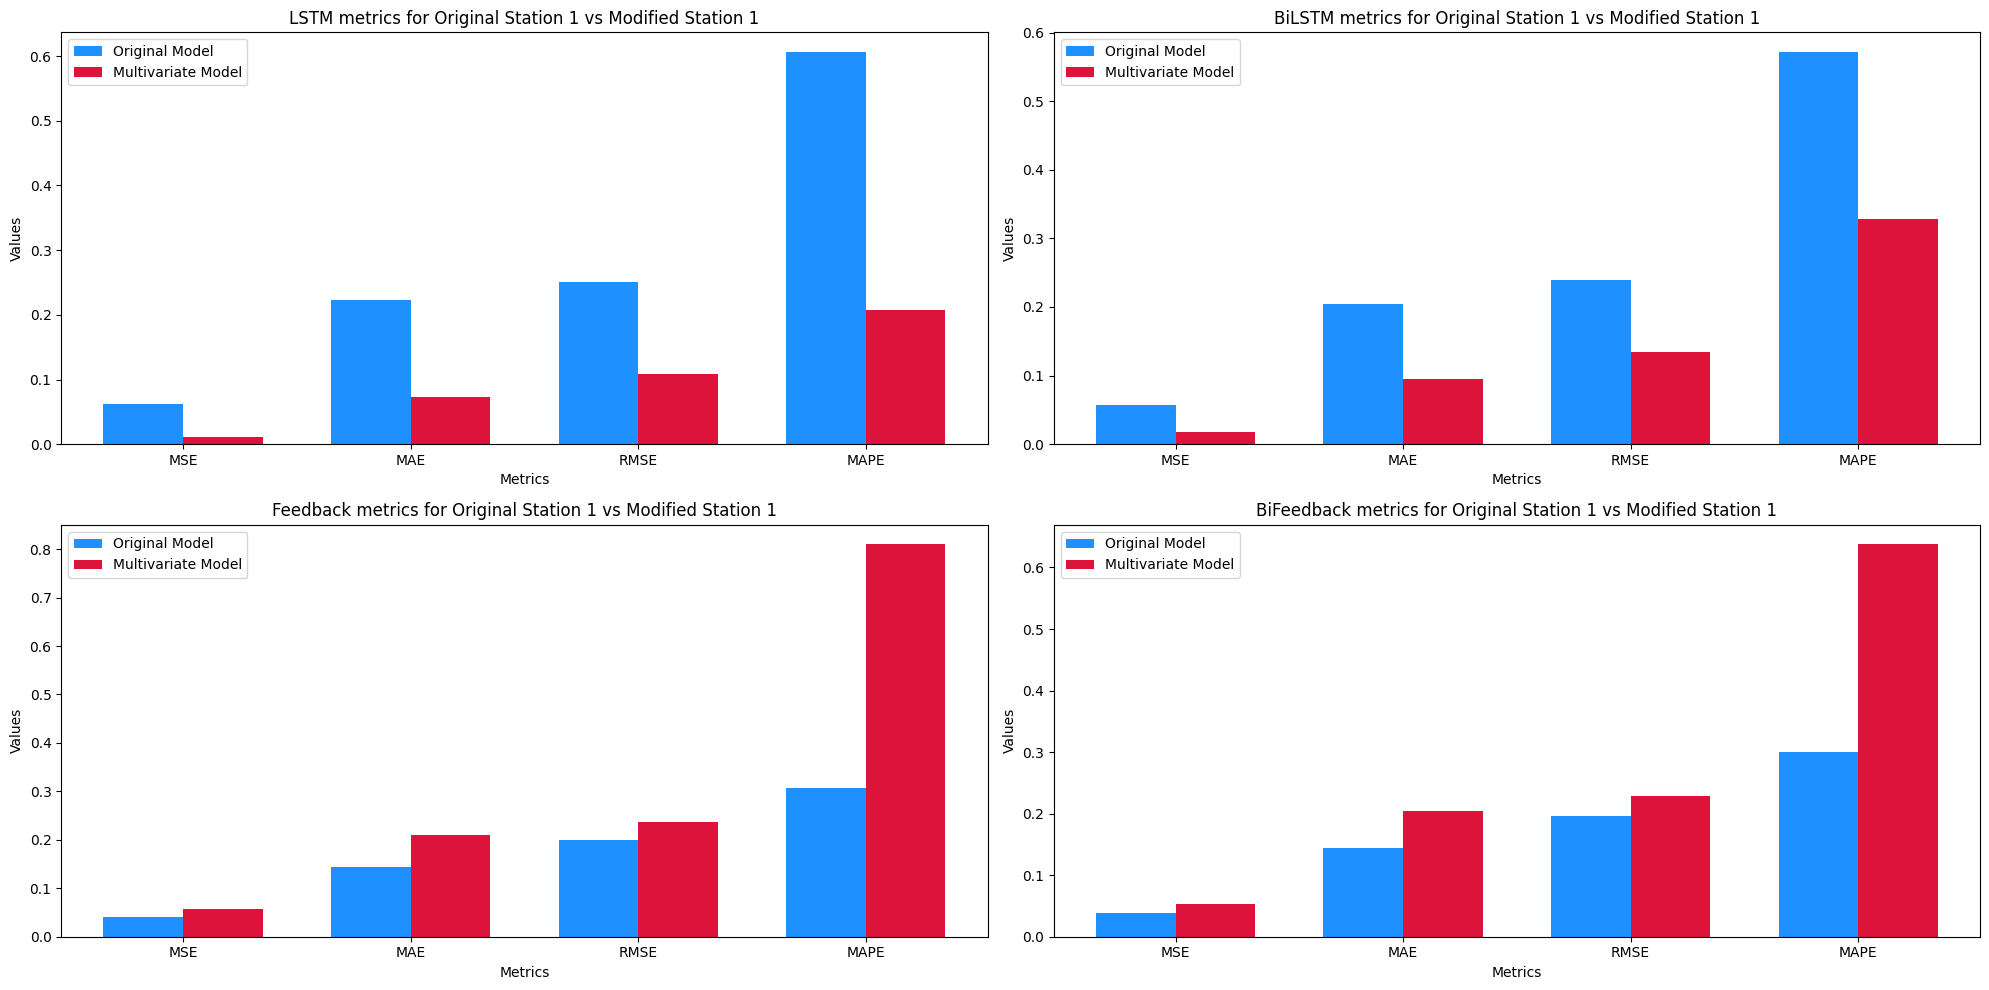

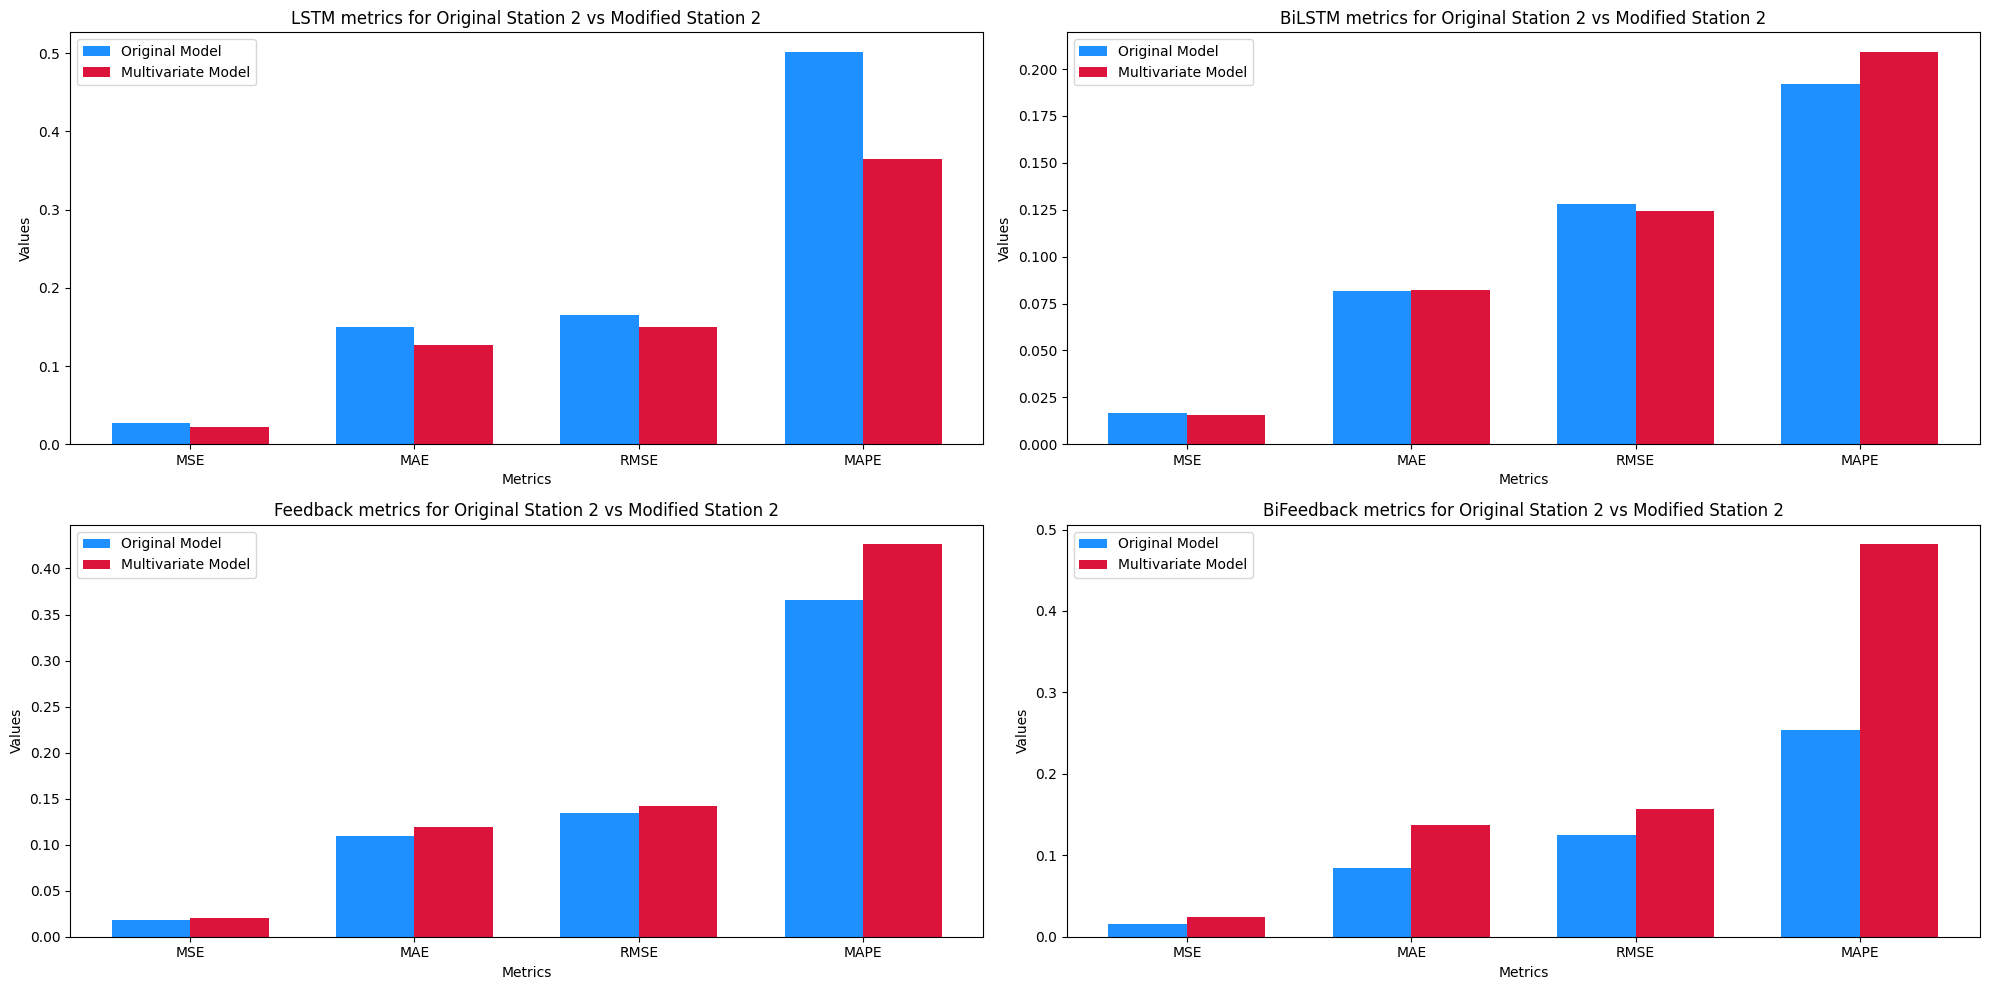

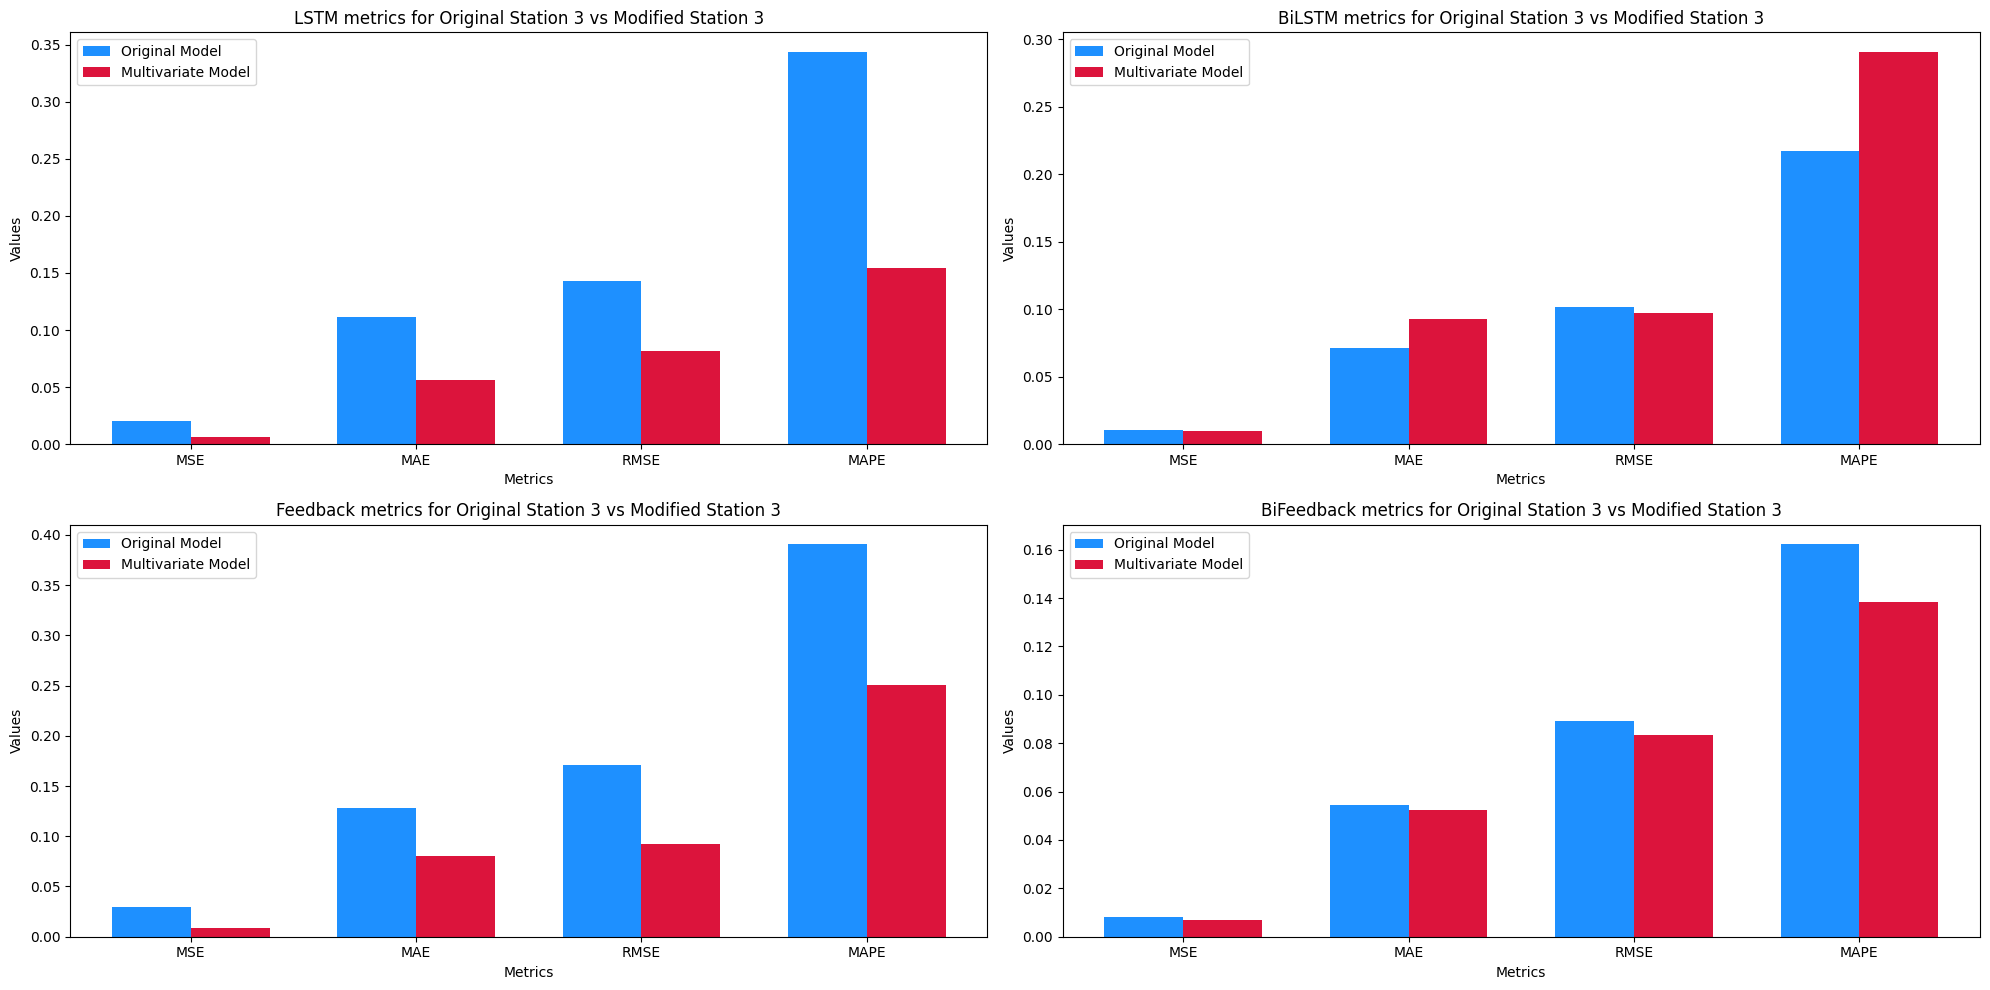

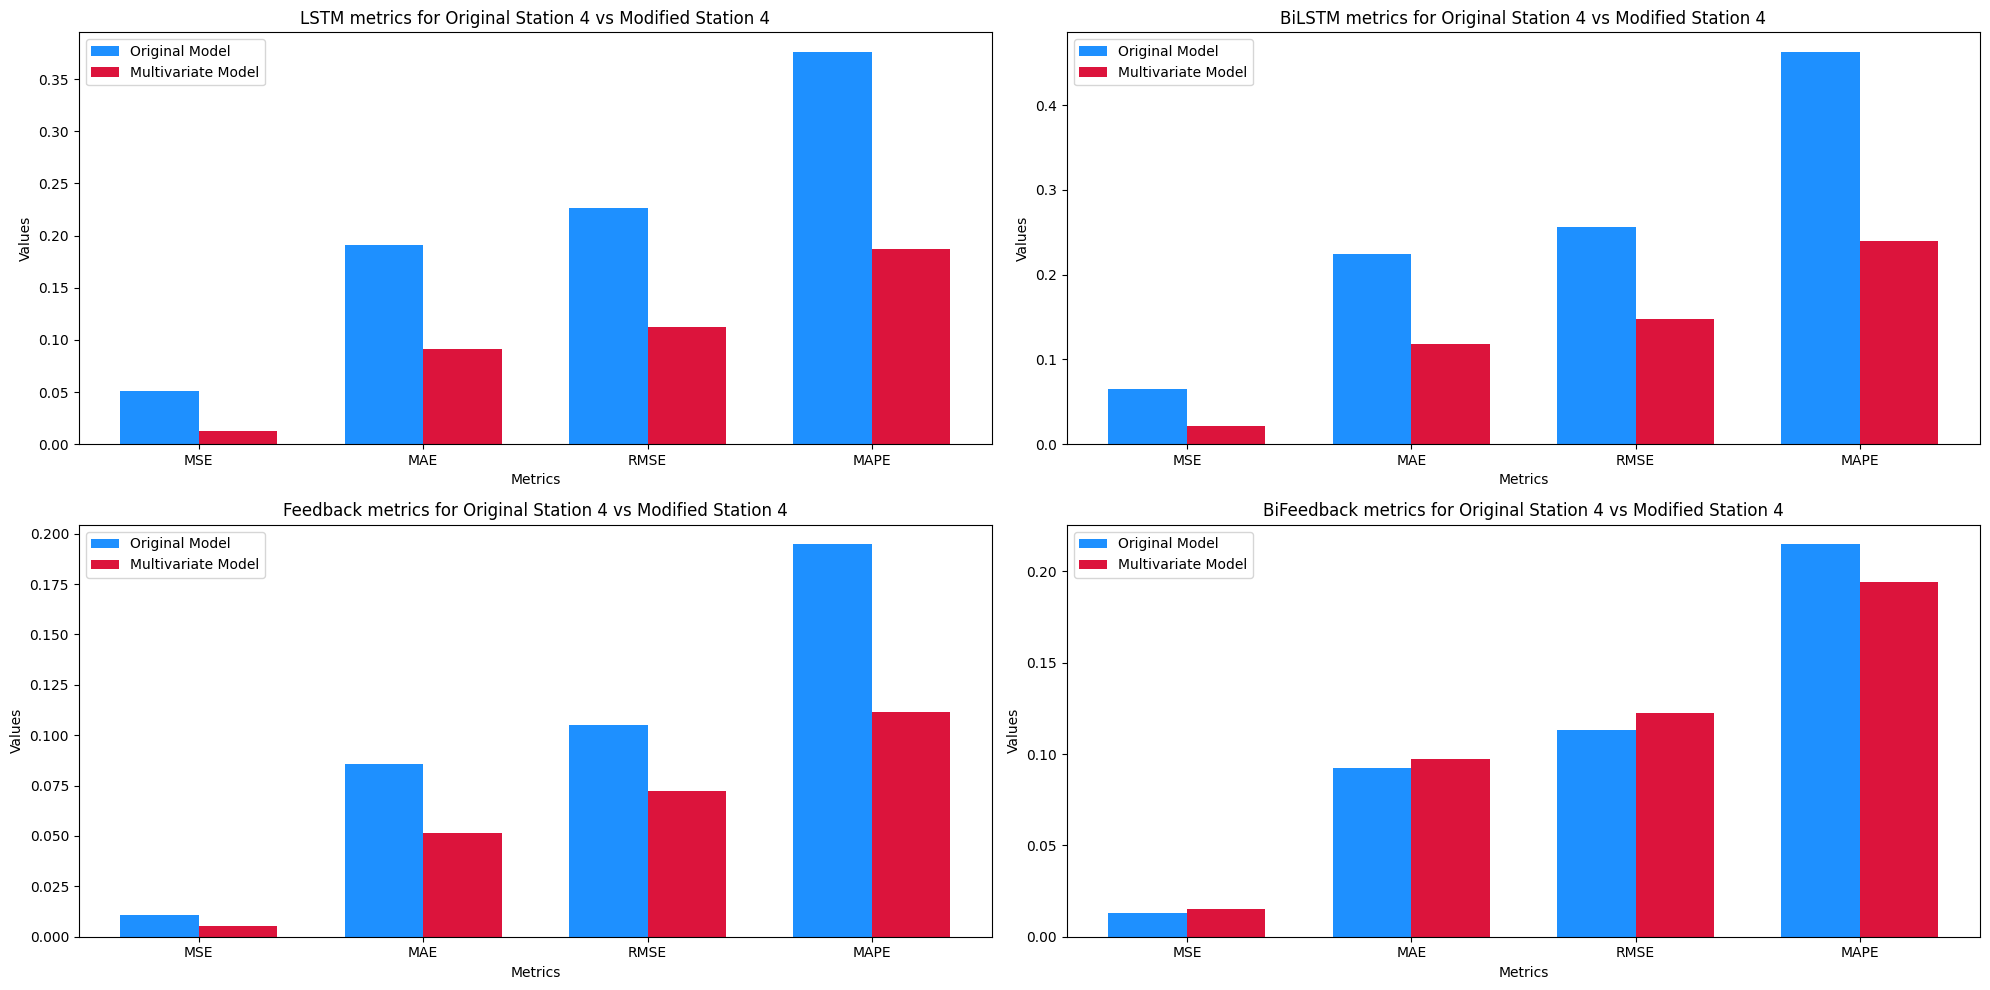

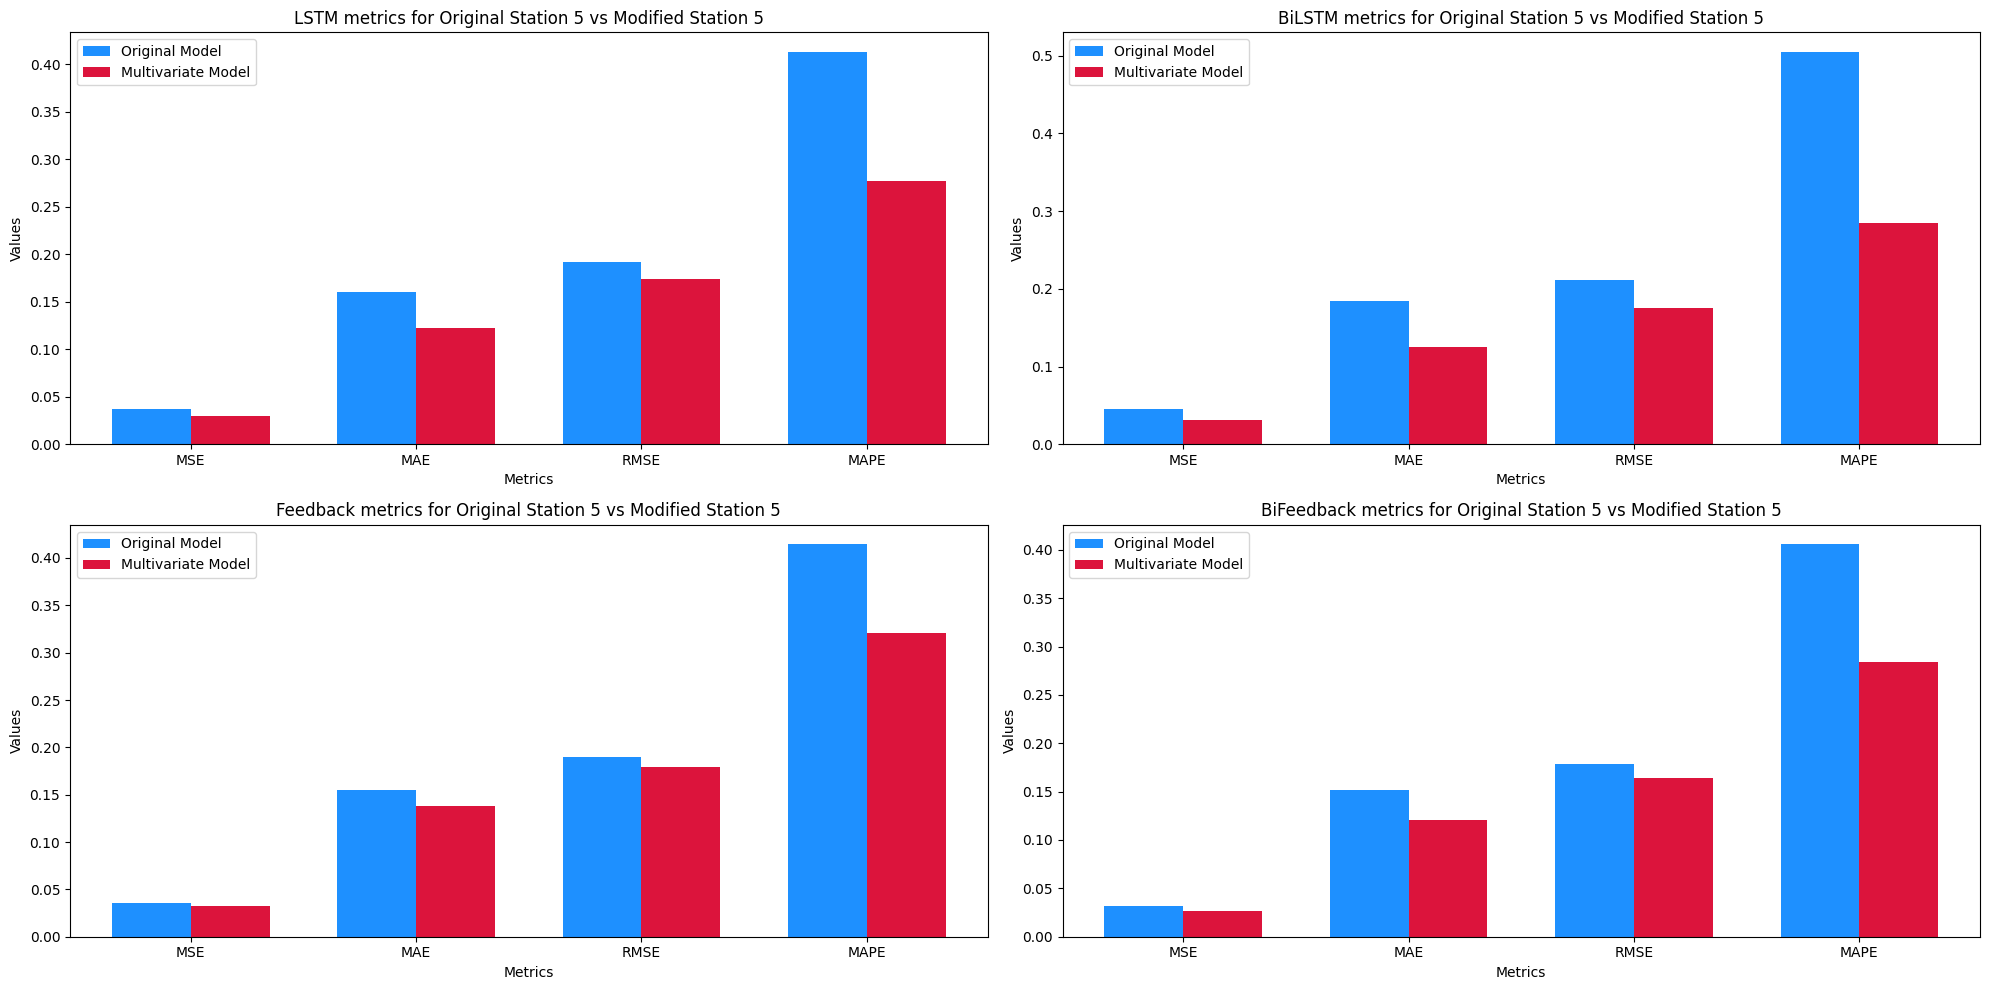

In [ ]:
station_pairs = [(1, 6), (2, 7), (3, 8), (4, 9), (5, 10)]
models = ['LSTM', 'BiLSTM', 'Feedback', 'BiFeedback']

for stations_pair in station_pairs:
    filename = f"comparison_{stations_pair[0]}_{stations_pair[1]}"
    plot_comparisons(stations_pair, models, df, filename)

In [ ]:
import pandas as pd
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.pyplot as plt
import six

# Create a DataFrame for the rain categories
rain_data = {
    "Precipitation (ppt)": ["0 mm", "> 0 - 0.1 mm", "> 0.1 - 0.2 mm", "> 0.2 - 0.3 mm", "> 0.3 - 0.5 mm",
                            "> 0.5 - 0.7 mm", "> 0.7 - 1.0 mm", "> 1.0 - 1.5 mm", "> 1.5 - 2.0 mm",
                            "> 2.0 - 2.5 mm", "> 2.5 - 3.0 mm", "> 3.0 - 3.5 mm", "> 3.5 - 4.0 mm", "> 4.0 mm"],
    "Category": ["No Rain", "Very Light", "Light Rain", "Light Rain", "Light Rain",
                 "Moderate", "Moderate", "Heavy", "Heavy", "Very Heavy",
                 "Very Heavy", "Severe", "Severe", "Extreme"],
    "Predicted Rain Chance (%)": ["3%", "5%", "8%", "10%", "15%", "20%", "30%", "40%", "50%", "60%", "70%", "80%", "90%", "100%"]
}

df_rain = pd.DataFrame(rain_data)

# Save DataFrame to PDF
def save_df_to_pdf(df, filename):
    with PdfPages(filename) as pdf:
        fig, ax = plt.subplots(figsize=(8, 5)) # Set figure size
        ax.axis('tight')
        ax.axis('off')
        the_table = ax.table(cellText=df.values, colLabels=df.columns, loc='center')

        # Adjust layout to make room for the table:
        plt.subplots_adjust(left=0.2, right=0.8)

        plt.savefig(f"{filename}.pdf", format='pdf')




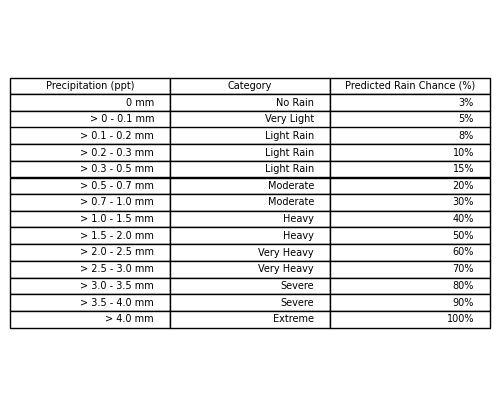

In [ ]:
save_df_to_pdf(df_rain, "raincategor")

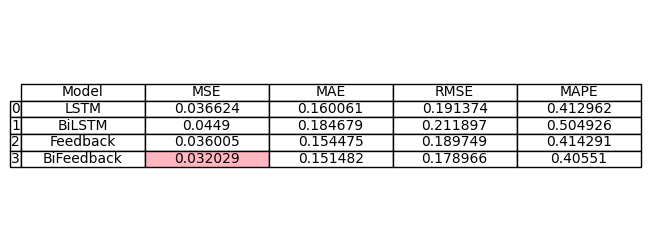

In [ ]:
df = pd.DataFrame({
    "Model": ["LSTM", "BiLSTM", "Feedback", "BiFeedback"],
    "MSE": [0.036624, 0.044900, 0.036005, 0.032029],
    "MAE": [0.160061, 0.184679, 0.154475, 0.151482],
    "RMSE": [0.191374, 0.211897, 0.189749, 0.178966],
    "MAPE": [0.412962, 0.504926, 0.414291, 0.405510]
})

# Identify the minimum values in the DataFrame
min_mse_value = df['MSE'].min()

# Creating a figure to plot table using `table` from Pandas Plotting
fig, ax = plt.subplots(figsize=(8, 3))  # Set size frame
ax.axis('off')

# Create the table
tbl = table(ax, df, loc='center', cellLoc='center')

# Highlight the minimum MSE value in lightpink
for (i, j), val in np.ndenumerate(df.values):
    if val == min_mse_value and df.columns[j] == 'MSE':
        tbl._cells[(i+1, j)].set_facecolor('lightpink')

plt.savefig('tableog.pdf', format='pdf')

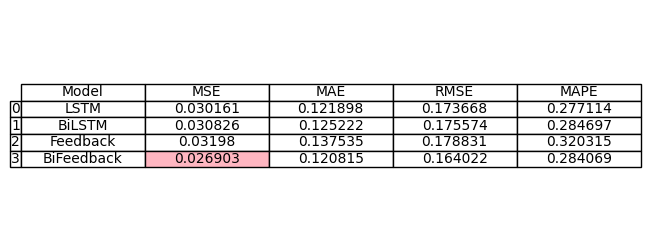

In [ ]:
df = pd.DataFrame({
    "Model": ["LSTM", "BiLSTM", "Feedback", "BiFeedback"],
    "MSE": [0.030161, 0.030826, 0.031980, 0.026903],
    "MAE": [0.121898, 0.125222, 0.137535, 0.120815],
    "RMSE": [0.173668, 0.175574, 0.178831, 0.164022],
    "MAPE": [0.277114, 0.284697, 0.320315, 0.284069]
})

# Identify the minimum values in the DataFrame
min_mse_value = df['MSE'].min()

# Creating a figure to plot table using `table` from Pandas Plotting
fig, ax = plt.subplots(figsize=(8, 3))  # Set size frame
ax.axis('off')

# Create the table
tbl = table(ax, df, loc='center', cellLoc='center')

# Highlight the minimum MSE value in lightpink
for (i, j), val in np.ndenumerate(df.values):
    if val == min_mse_value and df.columns[j] == 'MSE':
        tbl._cells[(i+1, j)].set_facecolor('lightpink')

plt.savefig('tablemultivariant.pdf', format='pdf')

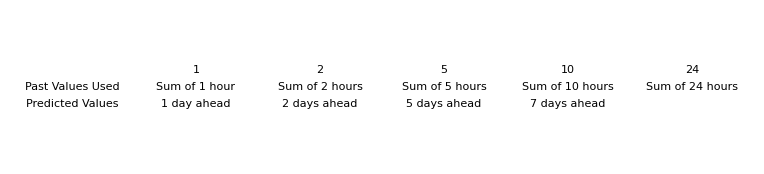

In [ ]:

# Data for the table
data = {
    '': ['Past Values Used', 'Predicted Values'],
    '1': ['Sum of 1 hour', '1 day ahead'],
    '2': ['Sum of 2 hours', '2 days ahead'],
    '5': ['Sum of 5 hours', '5 days ahead'],
    '10': ['Sum of 10 hours', '7 days ahead'],
    '24': ['Sum of 24 hours', '']
}

# Create a DataFrame
df = pd.DataFrame(data)

# Plot table
fig, ax = plt.subplots(figsize=(8, 2))  # Set size frame
ax.axis('tight')
ax.axis('off')
tbl = ax.table(cellText=df.values, colLabels=df.columns, loc='center', cellLoc='center', colWidths=[0.2]*len(df.columns))

# No values highlighted
for key, cell in tbl.get_celld().items():
    cell.set_linewidth(0)

# Save the table as a PDF
plt.savefig('sumtables.pdf', format='pdf', bbox_inches='tight')



In [ ]:
data = {
    "multivariate_LSTM": [0.007065, 0.060869, 0.084056, 0.125324],
    "multivariate_BiLSTM": [0.007190, 0.061209, 0.084796, 0.130775],
    "multivariate_Feedback": [0.005846, 0.053207, 0.076456, 0.106283],
    "multivariate_BiFeedback": [0.005781, 0.051992, 0.076034, 0.106409],
    "original_LSTM": [0.051348, 0.190536, 0.226602, 0.376073],
    "original_BiLSTM": [0.065530, 0.224473, 0.255988, 0.462867],
    "original_Feedback": [0.011004, 0.085718, 0.104901, 0.194658],
    "original_BiFeedback": [0.012822, 0.092612, 0.113236, 0.214718]
}

# Transforming the dictionary to DataFrame and setting the correct index
df_combined = pd.DataFrame(data, index=["MSE", "MAE", "RMSE", "MAPE"]).transpose()

In [ ]:
df_combined

,MSE,MAE,RMSE,MAPE
multivariate_LSTM,0.007065,0.060869,0.084056,0.125324
multivariate_BiLSTM,0.007190,0.061209,0.084796,0.130775
multivariate_Feedback,0.005846,0.053207,0.076456,0.106283
multivariate_BiFeedback,0.005781,0.051992,0.076034,0.106409
original_LSTM,0.051348,0.190536,0.226602,0.376073
original_BiLSTM,0.065530,0.224473,0.255988,0.462867
original_Feedback,0.011004,0.085718,0.104901,0.194658
original_BiFeedback,0.012822,0.092612,0.113236,0.214718


In [ ]:
import plotly.graph_objects as go
import pandas as pd

# Data for the graphs
data = {
    "cLSTM": [0.007065, 0.060869, 0.084056, 0.125324],
    "original_LSTM": [0.051348, 0.190536, 0.226602, 0.376073],
    "multivariate_BiLSTM": [0.007190, 0.061209, 0.084796, 0.130775],
    "original_BiLSTM": [0.065530, 0.224473, 0.255988, 0.462867],
    "multivariate_Feedback": [0.005846, 0.053207, 0.076456, 0.106283],
    "original_Feedback": [0.011004, 0.085718, 0.104901, 0.194658],
    "multivariate_BiFeedback": [0.005781, 0.051992, 0.076034, 0.106409],
    "original_BiFeedback": [0.012822, 0.092612, 0.113236, 0.214718]
}

# Metrics to plot
metrics = ["MSE", "MAE", "RMSE", "MAPE"]

# Create a figure with subplots for each model
fig = go.Figure()

# Adding bar plots for each model
for i, model in enumerate(["LSTM", "BiLSTM", "Feedback", "BiFeedback"]):
    fig.add_trace(go.Bar(
        name=f'Multivariate {model}',
        x=[f'{metric} - {model}' for metric in metrics],
        y=data[f'multivariate_{model}'],
        marker_color='rgba(55, 83, 109)',
    ))
    fig.add_trace(go.Bar(
        name=f'Original {model}',
        x=[f'{metric} - {model}' for metric in metrics],
        y=data[f'original_{model}'],
        marker_color='rgba(26, 118, 255)',
    ))

# Change the bar mode and layout
fig.update_layout(
    barmode='group',
    title='Comparison of Multivariate and Original Models on Different Metrics',
    xaxis_tickangle=-45,
    xaxis=dict(
        title='Model - Metric',
        titlefont_size=16,
        tickfont_size=14,
    ),
    yaxis=dict(
        title='Values',
        titlefont_size=16,
        tickfont_size=14,
    ),
    legend=dict(
        bgcolor='rgba(255, 255, 255, 0)',
        bordercolor='rgba(255, 255, 255, 0)'
    )
)

# Show figure
fig.show()


In [ ]:
import pandas as pd
import plotly.graph_objects as go

# Create the DataFrame for the new data
data = {
    "multivariate_LSTM": [0.028677, 0.130473, 0.169341, 0.309364],
    "multivariate_BiLSTM": [0.029048, 0.126816, 0.170434, 0.288986],
    "multivariate_Feedback": [0.029235, 0.137567, 0.170981, 0.333018],
    "multivariate_BiFeedback": [0.029410, 0.126930, 0.171495, 0.284707],
    "original_LSTM": [0.030864, 0.129494, 0.175682, 0.296364],
    "original_BiLSTM": [0.034782, 0.149843, 0.186498, 0.357329],
    "original_Feedback": [0.030534, 0.136292, 0.174739, 0.319835],
    "original_BiFeedback": [0.030483, 0.134034, 0.174593, 0.308750]
}

# Metrics to plot
metrics = ["MSE", "MAE", "RMSE", "MAPE"]

# Create a figure with subplots for each model
fig = go.Figure()

# Adding bar plots for each model
for i, model in enumerate(["LSTM", "BiLSTM", "Feedback", "BiFeedback"]):
    fig.add_trace(go.Bar(
        name=f'Multivariate {model}',
        x=[f'{metric} - {model}' for metric in metrics],
        y=data[f'multivariate_{model}'],
        marker_color='rgba(55, 83, 109)',
    ))
    fig.add_trace(go.Bar(
        name=f'Original {model}',
        x=[f'{metric} - {model}' for metric in metrics],
        y=data[f'original_{model}'],
        marker_color='rgba(26, 118, 255)',
    ))

# Change the bar mode and layout
fig.update_layout(
    barmode='group',
    title='Comparison of Multivariate and Original Models on Different Metrics',
    xaxis_tickangle=-45,
    xaxis=dict(
        title='Model - Metric',
        titlefont_size=16,
        tickfont_size=14,
    ),
    yaxis=dict(
        title='Values',
        titlefont_size=16,
        tickfont_size=14,
    ),
    legend=dict(
        bgcolor='rgba(255, 255, 255, 0)',
        bordercolor='rgba(255, 255, 255, 0)'
    )
)

# Show figure
fig.show()

